# UCI Datathon Project 2026: Emoji Prediction from Twitter Data

In [5]:
import pandas as pd
import re

# Load data
with open("tweets.txt", "r", encoding="utf-8") as f:
    tweets = [line.strip() for line in f.readlines()]

with open("emoji.txt", "r", encoding="utf-8") as f:
    emoji = [line.strip() for line in f.readlines()]

# safety check
assert len(tweets) == len(emoji), "Mismatch between number of tweets and emoji labels"

# create dataframe
df = pd.DataFrame({
    "text": tweets,
    "label": emoji
})

print("Original shape:", df.shape)
display(df.head())

# Basic checks
print("\nMissing values:")
print(df.isna().sum())

print("\nNumber of unique emoji labels:", df["label"].nunique())

print("\nClass distribution:")
display(df["label"].value_counts())

# Check duplicates
exact_dups = df.duplicated(subset=["text", "label"]).sum()
text_dups = df.duplicated(subset=["text"]).sum()

print("\nExact duplicate (text, label) rows:", exact_dups)
print("Duplicate text rows:", text_dups)

# conflicting labels for same text
conflicting_counts = df.groupby("text")["label"].nunique()
conflicting_texts = conflicting_counts[conflicting_counts > 1]

print("Texts with conflicting labels:", len(conflicting_texts))

# remove exact duplicate rows
df = df.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)

print("\nShape after removing exact duplicates:", df.shape)

# Text cleaning function
def clean_text(text):
    text = text.lower()
    
    # remove urls
    text = re.sub(r"http\S+|www\S+", "", text)
    
    # remove mentions
    text = re.sub(r"@\w+", "", text)
    
    # remove only # symbol, keep hashtag word
    text = re.sub(r"#", "", text)
    
    # remove RT only if it appears at the beginning
    text = re.sub(r"^rt\s+", "", text)
    
    # keep letters, spaces, ! ? '
    text = re.sub(r"[^a-z\s!?']", "", text)
    
    # normalize spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

# apply cleaning
df["clean_text"] = df["text"].apply(clean_text)

# Extra preprocessing info

# tweet length features for EDA
df["raw_length"] = df["text"].apply(len)
df["clean_length"] = df["clean_text"].apply(len)
df["word_count"] = df["clean_text"].apply(lambda x: len(x.split()))

print("\nSample cleaned data:")
display(df[["text", "clean_text", "label"]].head(10))

print("\nLength statistics:")
display(df[["raw_length", "clean_length", "word_count"]].describe())

print("\nFinal shape:", df.shape)
print("Preprocessing complete.")

Original shape: (225331, 2)


,text,label
0,RT @VibingOverHoes: Bet you'll get hungry htt...,heart_eyes
1,Starbucks employee confuses boyfriend by sayin...,yum
2,When your Starbucks store makes you an iced mo...,sob
3,"Being told ""girl your romper looks fierce!"" At...",blush
4,"I got a Starbucks drink at school today, shit ...",sob



Missing values:
text     0
label    0
dtype: int64

Number of unique emoji labels: 10

Class distribution:


label
sob           50525
heart_eyes    39193
weary         26855
blush         22894
wink          18078
yum           16790
smirk         15231
grin          15138
relaxed       10472
flushed       10155
Name: count, dtype: int64


Exact duplicate (text, label) rows: 54157
Duplicate text rows: 55387
Texts with conflicting labels: 792

Shape after removing exact duplicates: (171174, 2)

Sample cleaned data:


,text,clean_text,label
0,RT @VibingOverHoes: Bet you'll get hungry htt...,bet you'll get hungry,heart_eyes
1,Starbucks employee confuses boyfriend by sayin...,starbucks employee confuses boyfriend by sayin...,yum
2,When your Starbucks store makes you an iced mo...,when your starbucks store makes you an iced mo...,sob
3,"Being told ""girl your romper looks fierce!"" At...",being told girl your romper looks fierce! at t...,blush
4,"I got a Starbucks drink at school today, shit ...",i got a starbucks drink at school today shit t...,sob
5,So when is Starbucks getting their grill chees...,so when is starbucks getting their grill chees...,yum
6,really need @Jade_morgann to bring me some su...,really need to bring me some subway,weary
7,Bet you're feeling super salty now. https://t....,bet you're feeling super salty now,smirk
8,RT @Daniarmstrong88: So it's the end of #brang...,so it's the end of brangelina i bet a certain ...,grin
9,@ooohkarluuuh and forgot to get me Starbucks,and forgot to get me starbucks,sob



Length statistics:


,raw_length,clean_length,word_count
count,171174.000000,171174.000000,171174.000000
mean,69.452160,52.748081,10.539229
std,33.425302,31.723966,6.324537
min,5.000000,3.000000,1.000000
25%,43.000000,28.000000,6.000000
50%,63.000000,47.000000,9.000000
75%,93.000000,74.000000,15.000000
max,155.000000,146.000000,36.000000



Final shape: (171174, 6)
Preprocessing complete.


### TF-IDF 

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=3,
    max_features=5000
)

X = vectorizer.fit_transform(df["clean_text"])
y = df["label"]

In [7]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 136939
Test size: 34235


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, f1_score

### Naive Bayes

In [9]:
from sklearn.naive_bayes import MultinomialNB

nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=3,
        max_features=10000,
        sublinear_tf=True
    )),
    ("model", MultinomialNB())
])

print("Training Naive Bayes...")

nb_pipeline.fit(X_train, y_train)
nb_preds = nb_pipeline.predict(X_test)

nb_acc = accuracy_score(y_test, nb_preds)
nb_macro_f1 = f1_score(y_test, nb_preds, average="macro")
nb_weighted_f1 = f1_score(y_test, nb_preds, average="weighted")

print("Naive Bayes Results")
print("Accuracy:", nb_acc)
print("Macro F1:", nb_macro_f1)
print("Weighted F1:", nb_weighted_f1)
print("\nClassification Report:")
print(classification_report(y_test, nb_preds))

Training Naive Bayes...
Naive Bayes Results
Accuracy: 0.3472761793486198
Macro F1: 0.2230063502495389
Weighted F1: 0.29896854445524473

Classification Report:
              precision    recall  f1-score   support

       blush       0.27      0.20      0.23      3856
     flushed       0.93      0.05      0.10      1230
        grin       0.30      0.01      0.02      2158
  heart_eyes       0.40      0.52      0.45      5388
     relaxed       0.33      0.00      0.00      1555
       smirk       0.32      0.11      0.16      2299
         sob       0.34      0.70      0.46      7952
       weary       0.37      0.23      0.29      4516
        wink       0.29      0.35      0.32      2959
         yum       0.34      0.14      0.20      2322

    accuracy                           0.35     34235
   macro avg       0.39      0.23      0.22     34235
weighted avg       0.36      0.35      0.30     34235



### Logistic Regression

In [10]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=3,
        max_features=10000,
        sublinear_tf=True
    )),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

print("Training Logistic Regression...")

lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)

lr_acc = accuracy_score(y_test, lr_preds)
lr_macro_f1 = f1_score(y_test, lr_preds, average="macro")
lr_weighted_f1 = f1_score(y_test, lr_preds, average="weighted")

print("Logistic Regression Results")
print("Accuracy:", lr_acc)
print("Macro F1:", lr_macro_f1)
print("Weighted F1:", lr_weighted_f1)
print("\nClassification Report:")
print(classification_report(y_test, lr_preds))

Training Logistic Regression...
Logistic Regression Results
Accuracy: 0.2972396670074485
Macro F1: 0.2729036517286428
Weighted F1: 0.3079689800470141

Classification Report:
              precision    recall  f1-score   support

       blush       0.28      0.19      0.23      3856
     flushed       0.15      0.41      0.22      1230
        grin       0.13      0.15      0.14      2158
  heart_eyes       0.47      0.36      0.41      5388
     relaxed       0.13      0.24      0.17      1555
       smirk       0.20      0.31      0.25      2299
         sob       0.54      0.28      0.37      7952
       weary       0.35      0.34      0.35      4516
        wink       0.28      0.33      0.30      2959
         yum       0.24      0.38      0.30      2322

    accuracy                           0.30     34235
   macro avg       0.28      0.30      0.27     34235
weighted avg       0.35      0.30      0.31     34235



### Linear SVM

In [11]:
from sklearn.svm import LinearSVC

svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=3,
        max_features=10000,
        sublinear_tf=True
    )),
    ("model", LinearSVC(
        class_weight="balanced"
    ))
])

print("Training Linear SVM...")

svm_pipeline.fit(X_train, y_train)
svm_preds = svm_pipeline.predict(X_test)

svm_acc = accuracy_score(y_test, svm_preds)
svm_macro_f1 = f1_score(y_test, svm_preds, average="macro")
svm_weighted_f1 = f1_score(y_test, svm_preds, average="weighted")

print("Linear SVM Results")
print("Accuracy:", svm_acc)
print("Macro F1:", svm_macro_f1)
print("Weighted F1:", svm_weighted_f1)
print("\nClassification Report:")
print(classification_report(y_test, svm_preds))

Training Linear SVM...
Linear SVM Results
Accuracy: 0.3049802833357675
Macro F1: 0.2713155563141401
Weighted F1: 0.3146778263912683

Classification Report:
              precision    recall  f1-score   support

       blush       0.27      0.20      0.23      3856
     flushed       0.16      0.36      0.22      1230
        grin       0.14      0.14      0.14      2158
  heart_eyes       0.46      0.41      0.43      5388
     relaxed       0.13      0.21      0.16      1555
       smirk       0.20      0.30      0.24      2299
         sob       0.51      0.34      0.41      7952
       weary       0.35      0.30      0.32      4516
        wink       0.27      0.31      0.29      2959
         yum       0.24      0.32      0.28      2322

    accuracy                           0.30     34235
   macro avg       0.27      0.29      0.27     34235
weighted avg       0.34      0.30      0.31     34235



In [12]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "Linear SVM"],
    "Accuracy": [nb_acc, lr_acc, svm_acc],
    "Macro F1": [nb_macro_f1, lr_macro_f1, svm_macro_f1],
    "Weighted F1": [nb_weighted_f1, lr_weighted_f1, svm_weighted_f1]
}).sort_values(by="Macro F1", ascending=False)

display(results_df)

,Model,Accuracy,Macro F1,Weighted F1
1,Logistic Regression,0.297240,0.272904,0.307969
2,Linear SVM,0.304980,0.271316,0.314678
0,Naive Bayes,0.347276,0.223006,0.298969


### Sentence Transformer

In [13]:
!pip install -q sentence-transformers

In [14]:
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, f1_score

In [15]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")

X_emb = embedder.encode(
    df["clean_text"].tolist(),
    batch_size=64,
    show_progress_bar=True
)

y = df["label"]

print("Embeddings shape:", X_emb.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/2675 [00:00<?, ?it/s]

Embeddings shape: (171174, 384)


### Test Train Split

In [16]:
X_train_emb, X_test_emb, y_train, y_test = train_test_split(
    X_emb,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train_emb.shape)
print("Test shape:", X_test_emb.shape)

Train shape: (136939, 384)
Test shape: (34235, 384)


### Logistic Regression

In [17]:
lr_emb = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

print("Training SentenceTransformer + Logistic Regression...")

lr_emb.fit(X_train_emb, y_train)
lr_emb_preds = lr_emb.predict(X_test_emb)

lr_emb_acc = accuracy_score(y_test, lr_emb_preds)
lr_emb_macro_f1 = f1_score(y_test, lr_emb_preds, average="macro")
lr_emb_weighted_f1 = f1_score(y_test, lr_emb_preds, average="weighted")

print("SentenceTransformer + Logistic Regression Results")
print("Accuracy:", lr_emb_acc)
print("Macro F1:", lr_emb_macro_f1)
print("Weighted F1:", lr_emb_weighted_f1)
print("\nClassification Report:")
print(classification_report(y_test, lr_emb_preds))

Training SentenceTransformer + Logistic Regression...
SentenceTransformer + Logistic Regression Results
Accuracy: 0.26496275741200526
Macro F1: 0.24053538482041087
Weighted F1: 0.2716868978936739

Classification Report:
              precision    recall  f1-score   support

       blush       0.25      0.11      0.16      3856
     flushed       0.13      0.41      0.19      1230
        grin       0.14      0.11      0.12      2158
  heart_eyes       0.43      0.33      0.38      5388
     relaxed       0.11      0.19      0.14      1555
       smirk       0.18      0.29      0.22      2299
         sob       0.49      0.24      0.32      7952
       weary       0.33      0.31      0.32      4516
        wink       0.25      0.29      0.26      2959
         yum       0.22      0.41      0.29      2322

    accuracy                           0.26     34235
   macro avg       0.25      0.27      0.24     34235
weighted avg       0.32      0.26      0.27     34235



### Linear SVM

In [18]:
svm_emb = LinearSVC(class_weight="balanced")

print("Training SentenceTransformer + Linear SVM...")

svm_emb.fit(X_train_emb, y_train)
svm_emb_preds = svm_emb.predict(X_test_emb)

svm_emb_acc = accuracy_score(y_test, svm_emb_preds)
svm_emb_macro_f1 = f1_score(y_test, svm_emb_preds, average="macro")
svm_emb_weighted_f1 = f1_score(y_test, svm_emb_preds, average="weighted")

print("SentenceTransformer + Linear SVM Results")
print("Accuracy:", svm_emb_acc)
print("Macro F1:", svm_emb_macro_f1)
print("Weighted F1:", svm_emb_weighted_f1)
print("\nClassification Report:")
print(classification_report(y_test, svm_emb_preds))

Training SentenceTransformer + Linear SVM...
SentenceTransformer + Linear SVM Results
Accuracy: 0.2930334453045129
Macro F1: 0.24528682371165306
Weighted F1: 0.2919233783384942

Classification Report:
              precision    recall  f1-score   support

       blush       0.25      0.14      0.18      3856
     flushed       0.13      0.36      0.19      1230
        grin       0.15      0.05      0.08      2158
  heart_eyes       0.40      0.43      0.41      5388
     relaxed       0.12      0.10      0.11      1555
       smirk       0.20      0.26      0.23      2299
         sob       0.46      0.35      0.40      7952
       weary       0.33      0.28      0.30      4516
        wink       0.24      0.33      0.28      2959
         yum       0.23      0.37      0.28      2322

    accuracy                           0.29     34235
   macro avg       0.25      0.27      0.25     34235
weighted avg       0.31      0.29      0.29     34235



### Char TF IDF

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, f1_score

char_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char",
        ngram_range=(3,5),
        min_df=2,
        max_features=40000,
        sublinear_tf=True
    )),
    ("model", LinearSVC(class_weight="balanced"))
])

print("Training Character n-gram TF-IDF + Linear SVM...")

char_model.fit(X_train, y_train)

char_preds = char_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, char_preds))
print("Macro F1:", f1_score(y_test, char_preds, average="macro"))
print("Weighted F1:", f1_score(y_test, char_preds, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, char_preds))

Training Character n-gram TF-IDF + Linear SVM...
Accuracy: 0.3364393164889733
Macro F1: 0.30416983500736394
Weighted F1: 0.3444731843726228

Classification Report:
              precision    recall  f1-score   support

       blush       0.29      0.23      0.26      3856
     flushed       0.20      0.36      0.26      1230
        grin       0.18      0.20      0.19      2158
  heart_eyes       0.48      0.43      0.45      5388
     relaxed       0.17      0.26      0.20      1555
       smirk       0.24      0.34      0.28      2299
         sob       0.53      0.37      0.43      7952
       weary       0.37      0.34      0.35      4516
        wink       0.29      0.34      0.31      2959
         yum       0.26      0.35      0.30      2322

    accuracy                           0.34     34235
   macro avg       0.30      0.32      0.30     34235
weighted avg       0.37      0.34      0.34     34235



### Word + Char TF IDF

In [20]:
from sklearn.pipeline import FeatureUnion, Pipeline

word_vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=2,
    max_features=20000,
    sublinear_tf=True
)

char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3,5),
    min_df=2,
    max_features=20000,
    sublinear_tf=True
)

combined_features = FeatureUnion([
    ("word", word_vectorizer),
    ("char", char_vectorizer)
])

combined_model = Pipeline([
    ("features", combined_features),
    ("model", LinearSVC(class_weight="balanced"))
])

print("Training combined word + char model...")

combined_model.fit(X_train, y_train)

combined_preds = combined_model.predict(X_test)

combined_acc = accuracy_score(y_test, combined_preds)
combined_macro_f1 = f1_score(y_test, combined_preds, average="macro")
combined_weighted_f1 = f1_score(y_test, combined_preds, average="weighted")

print("Combined Model Results")
print("Accuracy:", combined_acc)
print("Macro F1:", combined_macro_f1)
print("Weighted F1:", combined_weighted_f1)

print("\nClassification Report:")
print(classification_report(y_test, combined_preds))

Training combined word + char model...
Combined Model Results
Accuracy: 0.3465459325251935
Macro F1: 0.3125516345176906
Weighted F1: 0.354203275798548

Classification Report:
              precision    recall  f1-score   support

       blush       0.30      0.25      0.28      3856
     flushed       0.21      0.34      0.26      1230
        grin       0.19      0.22      0.21      2158
  heart_eyes       0.48      0.44      0.46      5388
     relaxed       0.18      0.26      0.21      1555
       smirk       0.25      0.34      0.29      2299
         sob       0.53      0.39      0.45      7952
       weary       0.37      0.35      0.36      4516
        wink       0.30      0.34      0.32      2959
         yum       0.28      0.34      0.30      2322

    accuracy                           0.35     34235
   macro avg       0.31      0.33      0.31     34235
weighted avg       0.37      0.35      0.35     34235



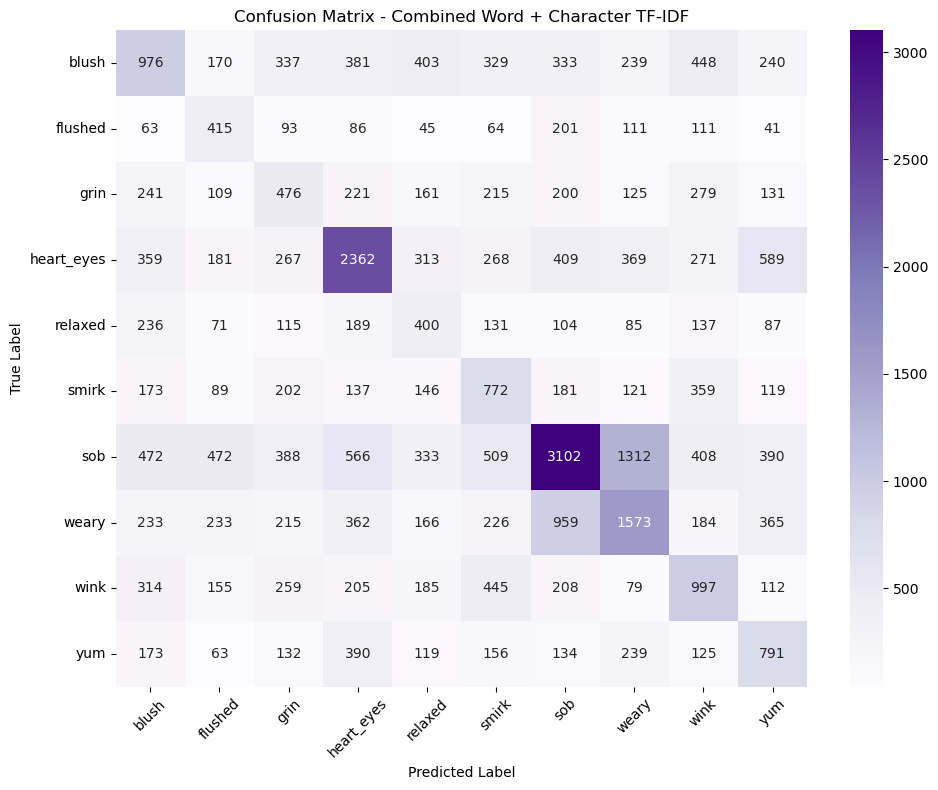

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm_combined = confusion_matrix(y_test, combined_preds)

# get sorted unique labels
labels = np.unique(y_test)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm_combined,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Combined Word + Character TF-IDF")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Ensemble Model

In [21]:
from sklearn.ensemble import VotingClassifier

ensemble_model = VotingClassifier(
    estimators=[
        ("nb", nb_pipeline),
        ("combined_svm", combined_model)
    ],
    voting="hard"
)

print("Training ensemble")

ensemble_model.fit(X_train, y_train)

ensemble_preds = ensemble_model.predict(X_test)

print("Ensemble Results")
print("Accuracy:", accuracy_score(y_test, ensemble_preds))
print("Macro F1:", f1_score(y_test, ensemble_preds, average="macro"))
print("Weighted F1:", f1_score(y_test, ensemble_preds, average="weighted"))

print(classification_report(y_test, ensemble_preds))

Training ensemble
Ensemble Results
Accuracy: 0.3484153643931649
Macro F1: 0.28228868926425493
Weighted F1: 0.3356127737349886
              precision    recall  f1-score   support

       blush       0.27      0.35      0.30      3856
     flushed       0.21      0.33      0.26      1230
        grin       0.19      0.19      0.19      2158
  heart_eyes       0.42      0.56      0.48      5388
     relaxed       0.15      0.13      0.14      1555
       smirk       0.25      0.30      0.28      2299
         sob       0.44      0.51      0.47      7952
       weary       0.41      0.21      0.27      4516
        wink       0.37      0.21      0.27      2959
         yum       0.38      0.11      0.17      2322

    accuracy                           0.35     34235
   macro avg       0.31      0.29      0.28     34235
weighted avg       0.35      0.35      0.34     34235



### XGBoost + Sentense Embeddings

In [22]:
!pip install -q xgboost

In [23]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, f1_score

In [24]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(df["label"])

In [25]:
from sklearn.model_selection import train_test_split

X_train_emb, X_test_emb, y_train_enc, y_test_enc = train_test_split(
    X_emb,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

In [26]:
xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=len(label_encoder.classes_),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42
)

print("Training XGBoost on sentence embeddings...")

xgb_model.fit(X_train_emb, y_train_enc)

xgb_preds_enc = xgb_model.predict(X_test_emb)

xgb_acc = accuracy_score(y_test_enc, xgb_preds_enc)
xgb_macro_f1 = f1_score(y_test_enc, xgb_preds_enc, average="macro")
xgb_weighted_f1 = f1_score(y_test_enc, xgb_preds_enc, average="weighted")

print("XGBoost + Embeddings Results")
print("Accuracy:", xgb_acc)
print("Macro F1:", xgb_macro_f1)
print("Weighted F1:", xgb_weighted_f1)

print("\nClassification Report:")
print(classification_report(
    y_test_enc,
    xgb_preds_enc,
    target_names=label_encoder.classes_
))

Training XGBoost on sentence embeddings...
XGBoost + Embeddings Results
Accuracy: 0.3705564480794509
Macro F1: 0.2673299350388404
Weighted F1: 0.3289052021141716

Classification Report:
              precision    recall  f1-score   support

       blush       0.32      0.24      0.27      3856
     flushed       0.77      0.13      0.22      1230
        grin       0.60      0.05      0.09      2158
  heart_eyes       0.41      0.56      0.47      5388
     relaxed       0.70      0.05      0.09      1555
       smirk       0.40      0.14      0.21      2299
         sob       0.36      0.72      0.48      7952
       weary       0.39      0.22      0.28      4516
        wink       0.32      0.31      0.32      2959
         yum       0.38      0.18      0.24      2322

    accuracy                           0.37     34235
   macro avg       0.46      0.26      0.27     34235
weighted avg       0.41      0.37      0.33     34235



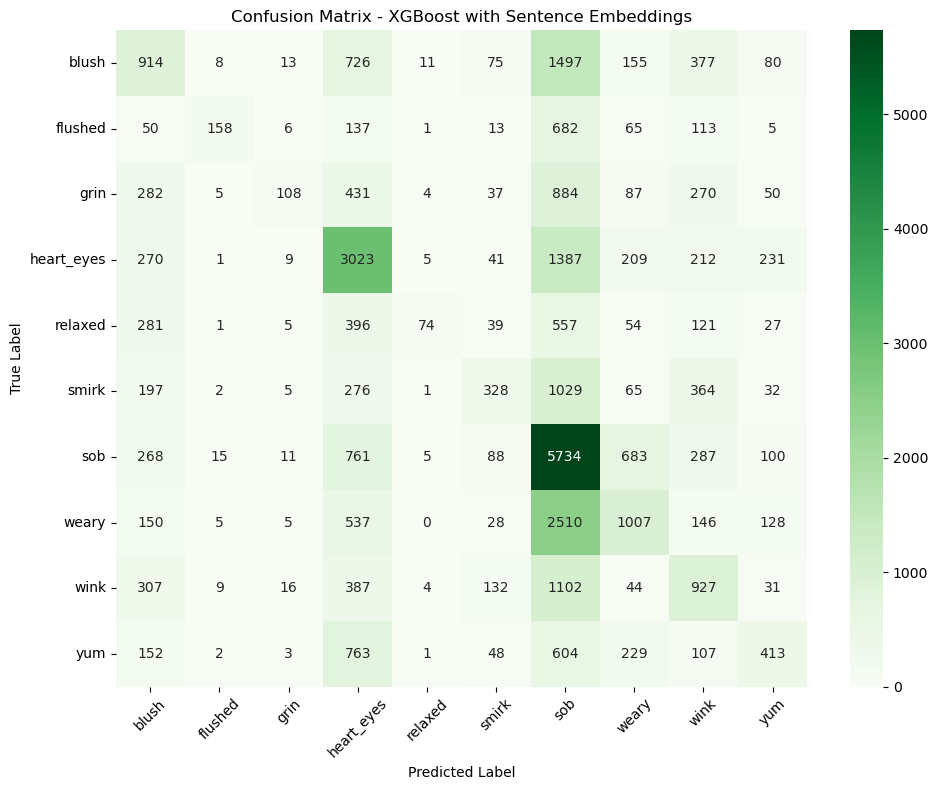

In [34]:
cm_xgb = confusion_matrix(y_test_enc, xgb_preds_enc)

labels = label_encoder.classes_

plt.figure(figsize=(10,8))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - XGBoost with Sentence Embeddings")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()